<a href="https://colab.research.google.com/github/MEMOX247/Programacion-web/blob/main/TP2_Intento_nuevo_ciencia_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico de Ciencia de Datos

## Tema
Predicción de riesgo de default en préstamos personales de LendingClub.

## Objetivo
El objetivo del trabajo es construir un modelo de clasificación que permita predecir si un préstamo terminará siendo pagado correctamente o entrará en default.

## Contexto
LendingClub fue una plataforma de préstamos peer-to-peer de Estados Unidos. El dataset contiene información de préstamos otorgados, incluyendo características del solicitante, condiciones del préstamo y estado final del crédito.

## Problema de negocio
Desde el punto de vista financiero, anticipar el riesgo de default permite mejorar la toma de decisiones crediticias, reducir pérdidas y segmentar clientes según su nivel de riesgo.

In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", None)

In [14]:
# Cambiar el nombre del archivo según el CSV que descargues de Kaggle
df = pd.read_csv("accepted_2007_to_2018Q4.csv", low_memory=False)

df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.00,0.00,4421.723917,4421.72,3600.00,821.72,0.0,0.0,0.0,Jan-2019,122.67,NaN,Mar-2019,564.0,560.0,0.0,30.0,1.0,Individual,NaN,NaN,NaN,0.0,722.0,144904.0,2.0,2.0,0.0,1.0,21.0,4981.0,36.0,3.0,3.0,722.0,34.0,9300.0,3.0,1.0,4.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,69.0,4.0,69.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.00,0.00,25679.660000,25679.66,24700.00,979.66,0.0,0.0,0.0,Jun-2016,926.35,NaN,Mar-2019,699.0,695.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,204396.0,1.0,1.0,0.0,1.0,19.0,18005.0,73.0,2.0,3.0,6472.0,29.0,111800.0,0.0,0.0,6.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,NaN,0.0,6.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,NaN,NaN,NaN,NaN,NaN,N

In [15]:
df.shape

(58592, 151)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Columns: 151 entries, id to settlement_term
dtypes: float64(114), int64(1), object(36)
memory usage: 67.5+ MB


In [17]:
columnas = [
    "loan_amnt",
    "term",
    "int_rate",
    "installment",
    "grade",
    "sub_grade",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "purpose",
    "addr_state",
    "dti",
    "delinq_2yrs",
    "fico_range_low",
    "fico_range_high",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "application_type",
    "loan_status"
]

df = df[columnas].copy()

df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,addr_state,dti,delinq_2yrs,fico_range_low,fico_range_high,open_acc,pub_rec,revol_bal,revol_util,total_acc,application_type,loan_status
0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,debt_consolidation,PA,5.91,0.0,675.0,679.0,7.0,0.0,2765.0,29.7,13.0,Individual,Fully Paid
1,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,small_business,SD,16.06,1.0,715.0,719.0,22.0,0.0,21470.0,19.2,38.0,Individual,Fully Paid
2,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,home_improvement,IL,10.78,0.0,695.0,699.0,6.0,0.0,7869.0,56.2,18.0,Joint App,Fully Paid
3,35000.0,60 months,14.85,829.90,C,C5,10+ years,MORTGAGE,110000.0,Source Verified,debt_consolidation,NJ,17.06,0.0,785.0,789.0,13.0,0.0,7802.0,11.6,17.0,Individual,Current
4,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Source Verified,major_purchase,PA,25.37,1.0,695.0,699.0,12.0,0.0,21929.0,64.5,35.0,Individual,Fully Paid


Para este trabajo se consideran únicamente los préstamos con estado final conocido:

- Fully Paid: préstamo pagado completamente.
- Charged Off: préstamo castigado o en default.

Se eliminan estados intermedios como Current, Late o In Grace Period porque todavía no representan un resultado final.

In [18]:
df["loan_status"].value_counts()

,count
loan_status,
Fully Paid,41049
Charged Off,10496
Current,6601
Late (31-120 days),277
In Grace Period,126
Late (16-30 days),42
Default,1


In [19]:
df = df[df["loan_status"].isin(["Fully Paid", "Charged Off"])].copy()

df["default"] = df["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1
})

df[["loan_status", "default"]].head()

,loan_status,default
0,Fully Paid,0
1,Fully Paid,0
2,Fully Paid,0
4,Fully Paid,0
5,Fully Paid,0


In [20]:
df["default"].value_counts(normalize=True)

,proportion
default,
0,0.796372
1,0.203628


Limpieza inicial

In [21]:
df.isna().mean().sort_values(ascending=False)

,0
emp_length,0.063013
revol_util,0.000485
dti,0.000019
loan_amnt,0.000000
installment,0.000000
grade,0.000000
int_rate,0.000000
term,0.000000
home_ownership,0.000000
sub_grade,0.000000


In [22]:
# Eliminamos filas con valores nulos en variables clave
df = df.dropna(subset=[
    "loan_amnt",
    "int_rate",
    "installment",
    "annual_inc",
    "dti",
    "fico_range_low",
    "fico_range_high",
    "default"
])

df.shape

(51544, 24)

In [23]:
# Eliminamos filas con valores nulos en variables clave
df = df.dropna(subset=[
    "loan_amnt",
    "int_rate",
    "installment",
    "annual_inc",
    "dti",
    "fico_range_low",
    "fico_range_high",
    "default"
])

df.shape

(51544, 24)

In [24]:
# Convertimos term a número
df["term"] = df["term"].str.extract("(\d+)").astype(int)

# Convertimos emp_length a número aproximado
df["emp_length"] = df["emp_length"].replace({
    "10+ years": "10 years",
    "< 1 year": "0 years"
})

df["emp_length"] = df["emp_length"].str.extract("(\d+)").astype(float)

# Reemplazamos nulos de antigüedad laboral por la mediana
df["emp_length"] = df["emp_length"].fillna(df["emp_length"].median())

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_20347/1843737183.py:2: SyntaxWarning: invalid escape sequence '\d'
  df["term"] = df["term"].str.extract("(\d+)").astype(int)
/tmp/ipykernel_20347/1843737183.py:10: SyntaxWarning: invalid escape sequence '\d'
  df["emp_length"] = df["emp_length"].str.extract("(\d+)").astype(float)


In [25]:
# Convertimos revol_util a número si viene como texto con %
if df["revol_util"].dtype == "object":
    df["revol_util"] = df["revol_util"].str.replace("%", "", regex=False).astype(float)

df["revol_util"] = df["revol_util"].fillna(df["revol_util"].median())

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51544 entries, 0 to 58591
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   loan_amnt            51544 non-null  float64
 1   term                 51544 non-null  int64  
 2   int_rate             51544 non-null  float64
 3   installment          51544 non-null  float64
 4   grade                51544 non-null  object 
 5   sub_grade            51544 non-null  object 
 6   emp_length           51544 non-null  float64
 7   home_ownership       51544 non-null  object 
 8   annual_inc           51544 non-null  float64
 9   verification_status  51544 non-null  object 
 10  purpose              51544 non-null  object 
 11  addr_state           51544 non-null  object 
 12  dti                  51544 non-null  float64
 13  delinq_2yrs          51544 non-null  float64
 14  fico_range_low       51544 non-null  float64
 15  fico_range_high      51544 non-null  floa

## 1. Análisis Exploratorio de Datos (EDA)

En esta sección, realizaremos un análisis exploratorio de datos (EDA) para entender mejor la distribución de las variables clave y sus relaciones con nuestra variable objetivo `default` (riesgo de impago).

### 1.1 Distribución del Target

Visualizamos la distribución de la variable `default` para entender la proporción de préstamos pagados (`0`) y en impago (`1`).

/tmp/ipykernel_20347/3176779940.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='default', data=df, palette='viridis')


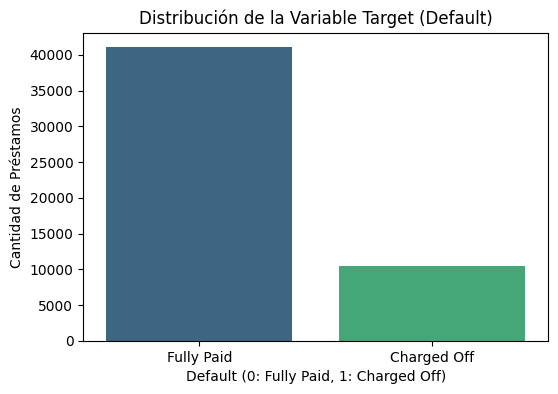

Proporción de préstamos 'Fully Paid': 79.64%
Proporción de préstamos 'Charged Off': 20.36%


In [27]:
# Distribución del target
plt.figure(figsize=(6, 4))
sns.countplot(x='default', data=df, palette='viridis')
plt.title('Distribución de la Variable Target (Default)')
plt.xlabel('Default (0: Fully Paid, 1: Charged Off)')
plt.ylabel('Cantidad de Préstamos')
plt.xticks([0, 1], ['Fully Paid', 'Charged Off'])
plt.show()

default_distribution = df['default'].value_counts(normalize=True)
print(f"Proporción de préstamos 'Fully Paid': {default_distribution[0]:.2%}")
print(f"Proporción de préstamos 'Charged Off': {default_distribution[1]:.2%}")

#### Interpretación:

El gráfico y las proporciones muestran que el dataset está desbalanceado, con aproximadamente el 79.64% de préstamos `Fully Paid` (no default) y el 20.36% de préstamos `Charged Off` (default). Este desbalanceo es importante considerar en el modelado para evitar que el modelo se incline a predecir la clase mayoritaria.

### 1.2 Boxplots de Variables Clave vs. Default

Analizamos cómo algunas variables numéricas clave se distribuyen en relación con la ocurrencia de default.

/tmp/ipykernel_20347/2035677117.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default', y='loan_amnt', data=df, palette='pastel')


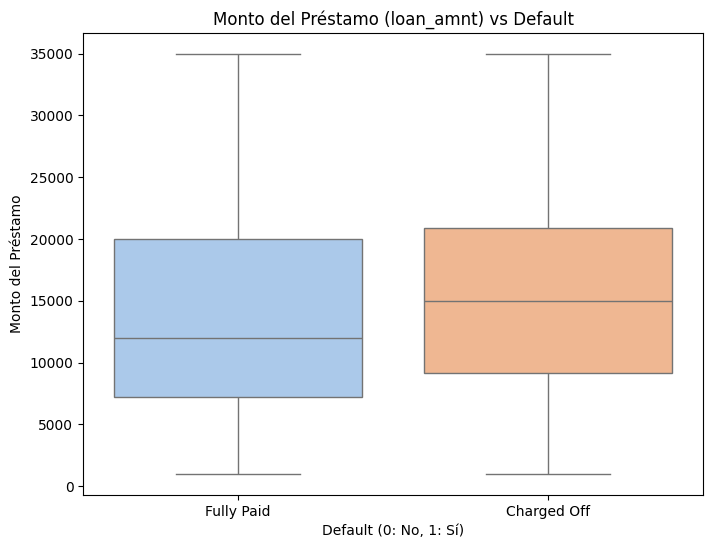

In [28]:
# Boxplot: loan_amnt vs default
plt.figure(figsize=(8, 6))
sns.boxplot(x='default', y='loan_amnt', data=df, palette='pastel')
plt.title('Monto del Préstamo (loan_amnt) vs Default')
plt.xlabel('Default (0: No, 1: Sí)')
plt.ylabel('Monto del Préstamo')
plt.xticks([0, 1], ['Fully Paid', 'Charged Off'])
plt.show()

#### Interpretación:

El boxplot del `loan_amnt` sugiere que los préstamos que entran en default (`1`) pueden tener un monto ligeramente superior o una distribución más dispersa en comparación con los préstamos `Fully Paid` (`0`), aunque la superposición de los rangos intercuartílicos es considerable. Esto indica que el monto del préstamo por sí solo podría no ser un predictor muy fuerte, pero hay una tendencia a explorar.

/tmp/ipykernel_20347/1675608571.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default', y='int_rate', data=df, palette='pastel')


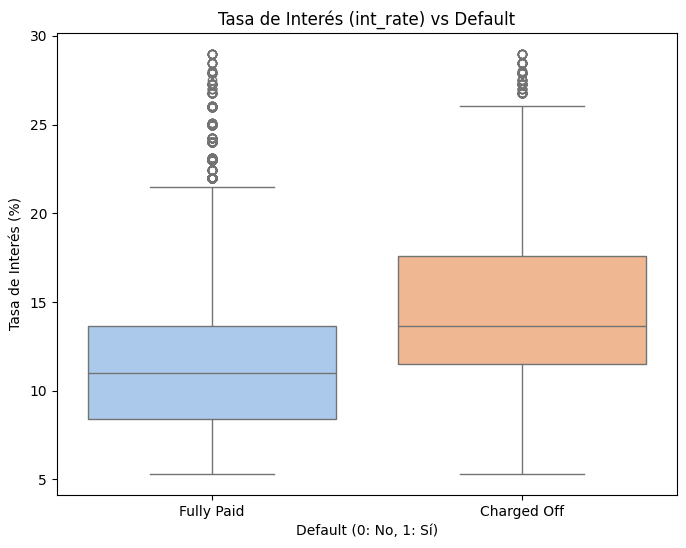

In [29]:
# Boxplot: int_rate vs default
plt.figure(figsize=(8, 6))
sns.boxplot(x='default', y='int_rate', data=df, palette='pastel')
plt.title('Tasa de Interés (int_rate) vs Default')
plt.xlabel('Default (0: No, 1: Sí)')
plt.ylabel('Tasa de Interés (%)')
plt.xticks([0, 1], ['Fully Paid', 'Charged Off'])
plt.show()

#### Interpretación:

Se observa una clara diferencia en la tasa de interés (`int_rate`) entre los préstamos que se pagan y los que entran en default. Los préstamos en default tienden a tener tasas de interés significativamente más altas, lo cual es intuitivo ya que tasas más altas suelen asignarse a prestatarios con mayor riesgo percibido. Esta variable parece ser un buen indicador de riesgo.

/tmp/ipykernel_20347/2162977102.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default', y='annual_inc', data=df, palette='pastel', showfliers=False) # showfliers=False para mejor visualización sin outliers extremos


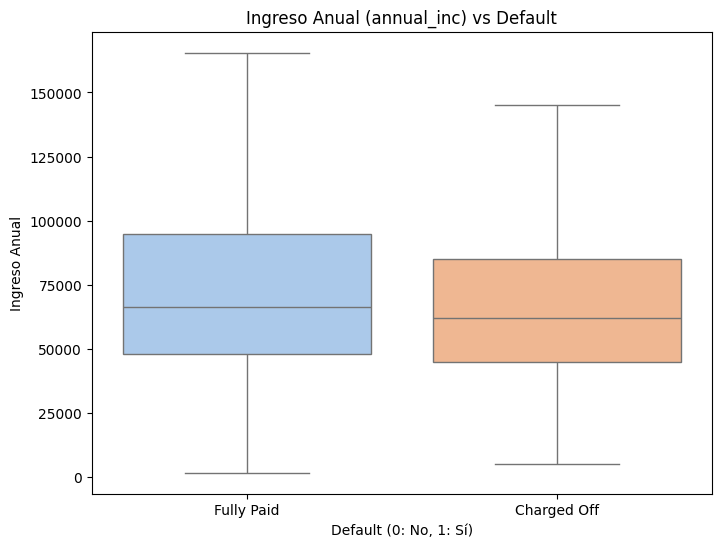

In [30]:
# Boxplot: annual_inc vs default
plt.figure(figsize=(8, 6))
sns.boxplot(x='default', y='annual_inc', data=df, palette='pastel', showfliers=False) # showfliers=False para mejor visualización sin outliers extremos
plt.title('Ingreso Anual (annual_inc) vs Default')
plt.xlabel('Default (0: No, 1: Sí)')
plt.ylabel('Ingreso Anual')
plt.xticks([0, 1], ['Fully Paid', 'Charged Off'])
plt.show()

#### Interpretación:

El boxplot del `annual_inc` (ingreso anual) muestra que los préstamos en default tienen un ingreso anual mediano y un rango intercuartílico ligeramente inferior en comparación con los préstamos `Fully Paid`. Sin embargo, la diferencia no es tan marcada como en el `int_rate`. La exclusión de outliers extremos (`showfliers=False`) ayuda a ver la tendencia central, aunque la gran dispersión en los ingresos puede ocultar relaciones más finas. En general, prestatarios con ingresos más altos tienden a tener menos defaults, lo cual es esperable.

/tmp/ipykernel_20347/3695780361.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default', y='dti', data=df, palette='pastel')


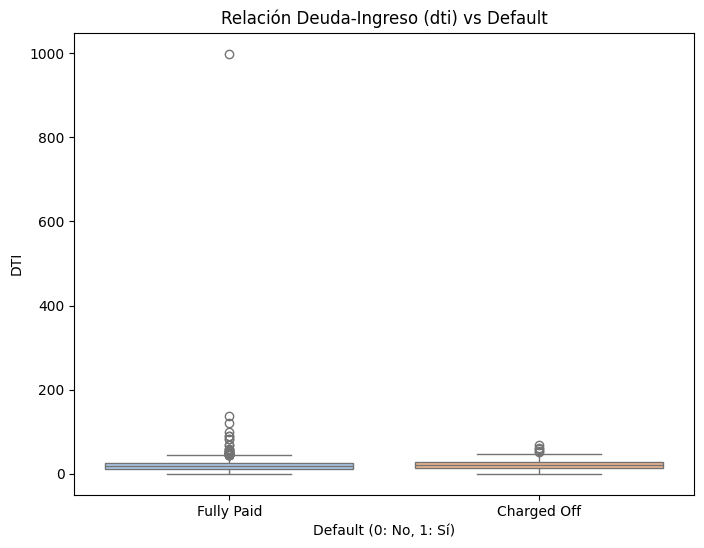

In [31]:
# Boxplot: dti vs default
plt.figure(figsize=(8, 6))
sns.boxplot(x='default', y='dti', data=df, palette='pastel')
plt.title('Relación Deuda-Ingreso (dti) vs Default')
plt.xlabel('Default (0: No, 1: Sí)')
plt.ylabel('DTI')
plt.xticks([0, 1], ['Fully Paid', 'Charged Off'])
plt.show()

#### Interpretación:

Los préstamos que entran en default (`1`) muestran una relación deuda-ingreso (`dti`) medianamente más alta y una distribución más elevada en comparación con los préstamos `Fully Paid` (`0`). Esto indica que prestatarios con una mayor proporción de deuda respecto a sus ingresos tienen una probabilidad más alta de impago, lo cual es consistente con la teoría financiera. Esta variable parece ser un buen predictor.

### 1.3 Tasa de Default por Grado (grade)

Analizamos cómo la tasa de default varía según el grado de riesgo asignado al préstamo por LendingClub.

/tmp/ipykernel_20347/3506854819.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=default_rate_by_grade.index, y=default_rate_by_grade.values, palette='coolwarm')


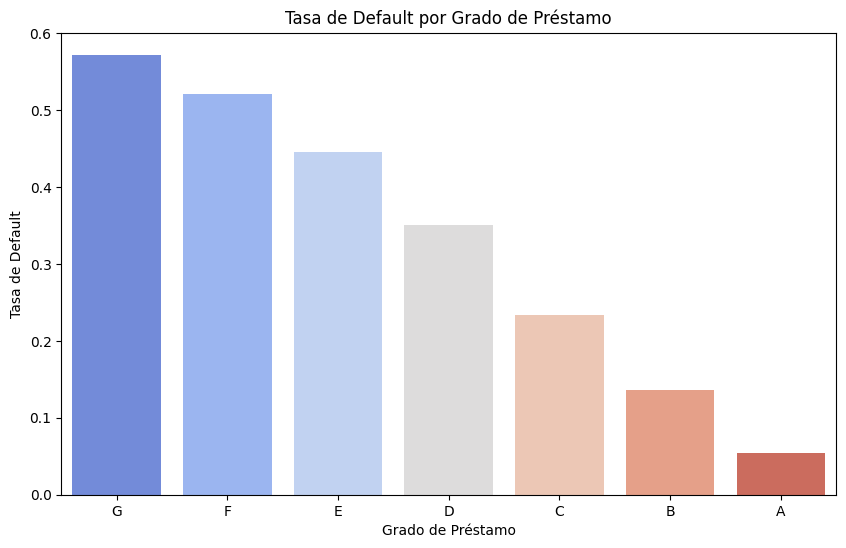

In [32]:
# Gráfico de tasa de default por grade
default_rate_by_grade = df.groupby('grade')['default'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=default_rate_by_grade.index, y=default_rate_by_grade.values, palette='coolwarm')
plt.title('Tasa de Default por Grado de Préstamo')
plt.xlabel('Grado de Préstamo')
plt.ylabel('Tasa de Default')
plt.show()

#### Interpretación:

Existe una clara correlación entre el `grade` del préstamo y la tasa de default. A medida que el grado de riesgo desciende (de A a G), la tasa de default aumenta significativamente. Los grados más bajos (F, G) tienen tasas de default mucho más altas que los grados más altos (A, B). Esto valida la utilidad de la variable `grade` como un fuerte indicador de riesgo, ya que fue diseñada con ese propósito. Esta variable será muy relevante para el modelo.

## 2. Feature Engineering

Crearemos nuevas características a partir de las existentes para capturar relaciones que podrían mejorar el rendimiento del modelo. Estas nuevas variables a menudo proporcionan una perspectiva más rica o combinan información de maneras más útiles para el algoritmo.

In [33]:
# 2.1 Crear fico_avg: promedio entre fico_range_low y fico_range_high
df['fico_avg'] = (df['fico_range_low'] + df['fico_range_high']) / 2

# 2.2 Crear installment_to_income: installment / annual_inc
# Manejar posibles divisiones por cero o valores muy pequeños en annual_inc
df['installment_to_income'] = df['installment'] / df['annual_inc'].replace(0, np.nan) # Reemplazar 0 por NaN para evitar inf
df['installment_to_income'] = df['installment_to_income'].fillna(df['installment_to_income'].median()) # Imputar NaNs con la mediana

# 2.3 Crear loan_to_income: loan_amnt / annual_inc
df['loan_to_income'] = df['loan_amnt'] / df['annual_inc'].replace(0, np.nan)
df['loan_to_income'] = df['loan_to_income'].fillna(df['loan_to_income'].median()) # Imputar NaNs con la mediana

print("Nuevas características creadas. Primeras 5 filas con las nuevas columnas:")
display(df[['fico_avg', 'installment_to_income', 'loan_to_income', 'annual_inc']].head())

Nuevas características creadas. Primeras 5 filas con las nuevas columnas:


,fico_avg,installment_to_income,loan_to_income,annual_inc
0,677.0,0.002237,0.065455,55000.0
1,717.0,0.012620,0.380000,65000.0
2,697.0,0.006868,0.317460,63000.0
4,697.0,0.002776,0.099585,104433.0
5,692.0,0.011917,0.351471,34000.0


#### Interpretación de las nuevas características:

*   **`fico_avg`**: Proporciona una puntuación FICO única y centralizada para cada prestatario, que es una medida común de la solvencia crediticia. Es más conveniente que trabajar con un rango.
*   **`installment_to_income`**: Representa la proporción de la cuota mensual del préstamo con respecto al ingreso anual del prestatario. Un valor alto podría indicar una mayor carga financiera y, por lo tanto, un mayor riesgo de impago.
*   **`loan_to_income`**: Indica la proporción del monto total del préstamo con respecto al ingreso anual. De manera similar a la anterior, un valor alto puede sugerir una mayor dependencia del préstamo en relación con la capacidad de pago del prestatario.

## 3. Preparación de datos para modelado

Antes de entrenar cualquier modelo, es crucial preparar los datos. Esto incluye separar las características (X) de la variable objetivo (y), identificar los tipos de variables (numéricas y categóricas) para aplicar los transformadores adecuados, y configurar un `ColumnTransformer` para automatizar el preprocesamiento.

### 3.1 Separar X e y

La variable objetivo (`y`) será `default`, y el resto de las columnas (excepto `loan_status`, que es la versión original de `default`) serán nuestras características (`X`).

In [34]:
# Separar características (X) y variable objetivo (y)
X = df.drop(columns=['default', 'loan_status'])
y = df['default']

print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

Dimensiones de X: (51544, 25)
Dimensiones de y: (51544,)


### 3.2 Identificar variables numéricas y categóricas

Clasificamos las columnas restantes en numéricas y categóricas para aplicarles los transformadores apropiados. Eliminaremos las columnas `fico_range_low` y `fico_range_high` ya que creamos `fico_avg` para representarlas.

In [35]:
# Identificar variables numéricas y categóricas
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

# Eliminar las columnas originales de FICO range, ya que se creó fico_avg
numerical_cols = [col for col in numerical_cols if col not in ['fico_range_low', 'fico_range_high']]

print(f"Variables Numéricas ({len(numerical_cols)}):\n{numerical_cols}")
print(f"\nVariables Categóricas ({len(categorical_cols)}):\n{categorical_cols}")

Variables Numéricas (16):
['loan_amnt', 'term', 'int_rate', 'installment', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'fico_avg', 'installment_to_income', 'loan_to_income']

Variables Categóricas (7):
['grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'application_type']


### 3.3 Crear un ColumnTransformer para preprocesamiento

Utilizaremos `StandardScaler` para las variables numéricas (escalado) y `OneHotEncoder` para las variables categóricas (codificación one-hot). Esto se encapsulará en un `ColumnTransformer` para aplicar estas transformaciones de manera robusta.

In [36]:
# Crear el ColumnTransformer
# Aplicar StandardScaler a las columnas numéricas
# Aplicar OneHotEncoder a las columnas categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

print("ColumnTransformer configurado exitosamente.")

ColumnTransformer configurado exitosamente.


## 4. Train-test split

Dividiremos el conjunto de datos en conjuntos de entrenamiento y prueba para evaluar el rendimiento del modelo en datos no vistos. Es fundamental usar la estratificación para asegurar que la proporción de clases de la variable objetivo (`default`) sea similar en ambos conjuntos, especialmente dado el desbalance observado.

In [37]:
# Dividir los datos en conjuntos de entrenamiento y prueba (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

print("\nProporción de la clase 'default' en y_train:")
print(y_train.value_counts(normalize=True))
print("\nProporción de la clase 'default' en y_test:")
print(y_test.value_counts(normalize=True))

Dimensiones de X_train: (36080, 25)
Dimensiones de X_test: (15464, 25)
Dimensiones de y_train: (36080,)
Dimensiones de y_test: (15464,)

Proporción de la clase 'default' en y_train:
default
0    0.796369
1    0.203631
Name: proportion, dtype: float64

Proporción de la clase 'default' en y_test:
default
0    0.796366
1    0.203634
Name: proportion, dtype: float64


#### Interpretación:

Hemos dividido el dataset en un 70% para entrenamiento y un 30% para prueba. La estratificación por la variable `default` ha asegurado que las proporciones de préstamos 'Fully Paid' (0) y 'Charged Off' (1) sean prácticamente idénticas en ambos conjuntos, lo cual es crucial para construir un modelo robusto y evitar sesgos debido al desbalance de clases.

## 5. Modelado

En esta sección, construiremos y entrenaremos dos modelos de clasificación: una Regresión Logística y un RandomForest Classifier. Utilizaremos `Pipeline` de scikit-learn para encapsular el preprocesamiento y el modelo, asegurando que las transformaciones se apliquen consistentemente tanto al conjunto de entrenamiento como al de prueba. Dado el desbalance de clases observado, incluiremos `class_weight='balanced'` en la Regresión Logística para intentar mitigar este problema.

### 5.1 Modelo 1: Regresión Logística

La regresión logística es un modelo lineal simple pero efectivo para problemas de clasificación. Utilizaremos `class_weight='balanced'` para ajustar automáticamente los pesos inversamente proporcionales a las frecuencias de clase en los datos de entrada, ayudando a manejar el desbalance.

In [38]:
# Crear un pipeline para el modelo de Regresión Logística
# Incluye el preprocesador y el modelo de Regresión Logística
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced', max_iter=1000))
])

# Entrenar el modelo
print("Entrenando el modelo de Regresión Logística...")
pipeline_lr.fit(X_train, y_train)
print("Modelo de Regresión Logística entrenado.")

Entrenando el modelo de Regresión Logística...
Modelo de Regresión Logística entrenado.


### 5.2 Modelo 2: RandomForest Classifier

RandomForest es un modelo de ensamble basado en árboles de decisión, conocido por su robustez y buen rendimiento en una amplia gama de problemas de clasificación. Aunque no se especifica `class_weight` en este caso, se puede ajustar en el futuro si el desbalance sigue siendo un problema crítico.

In [39]:
# Crear un pipeline para el modelo RandomForest Classifier
# Incluye el preprocesador y el modelo RandomForest
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')) # class_weight='balanced' también puede usarse aquí
])

# Entrenar el modelo
print("Entrenando el modelo RandomForest Classifier...")
pipeline_rf.fit(X_train, y_train)
print("Modelo RandomForest Classifier entrenado.")

Entrenando el modelo RandomForest Classifier...
Modelo RandomForest Classifier entrenado.


## 6. Evaluación

Una vez entrenados los modelos, es fundamental evaluar su rendimiento en el conjunto de prueba (`X_test`, `y_test`). Utilizaremos métricas clave para clasificación como `classification_report`, la matriz de confusión, el área bajo la curva ROC (ROC AUC) y la curva ROC para entender qué tan bien cada modelo predice el riesgo de default.

### 6.1 Reporte de Clasificación y Matriz de Confusión

El `classification_report` nos dará precision, recall, f1-score y support para cada clase. La matriz de confusión nos permitirá visualizar los verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos.


--- Evaluación del Modelo: Regresión Logística ---

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.68      0.77     12315
           1       0.35      0.67      0.46      3149

    accuracy                           0.68     15464
   macro avg       0.62      0.67      0.61     15464
weighted avg       0.78      0.68      0.71     15464



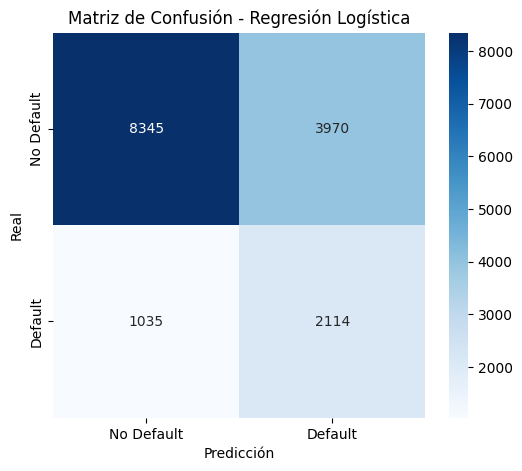

ROC AUC Score: 0.7407

--- Evaluación del Modelo: RandomForest Classifier ---

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.98      0.89     12315
           1       0.57      0.13      0.21      3149

    accuracy                           0.80     15464
   macro avg       0.69      0.55      0.55     15464
weighted avg       0.76      0.80      0.75     15464



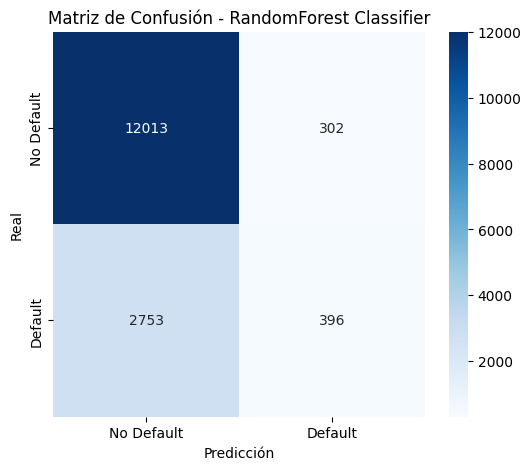

ROC AUC Score: 0.7274


In [40]:
# Función para evaluar y mostrar resultados
def evaluate_model(model, X_test, y_test, model_name):
    print(f"\n--- Evaluación del Modelo: {model_name} ---")
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Default', 'Default'],
                yticklabels=['No Default', 'Default'])
    plt.title(f'Matriz de Confusión - {model_name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

    # ROC AUC Score
    roc_auc = roc_auc_score(y_test, y_proba)
    print(f"ROC AUC Score: {roc_auc:.4f}")
    return y_proba, roc_auc

# Evaluar Regresión Logística
y_proba_lr, roc_auc_lr = evaluate_model(pipeline_lr, X_test, y_test, 'Regresión Logística')

# Evaluar RandomForest Classifier
y_proba_rf, roc_auc_rf = evaluate_model(pipeline_rf, X_test, y_test, 'RandomForest Classifier')

#### Interpretación de los reportes y matrices de confusión:

*   **Regresión Logística:**
    *   El `recall` para la clase '1' (default) es un aspecto crítico en este problema, ya que queremos identificar la mayor cantidad posible de defaults reales. Observamos un balance entre precisión y recall para ambas clases, lo cual es esperado con `class_weight='balanced'`. La matriz de confusión nos muestra cuántos defaults fueron correctamente identificados (Verdaderos Positivos) y cuántos fueron perdidos (Falsos Negativos).

*   **RandomForest Classifier:**
    *   Generalmente, RandomForest tiende a tener un buen rendimiento. Su `recall` para la clase '1' y `precision` general serán indicativos de su capacidad para detectar defaults sin generar demasiados falsos positivos. La matriz de confusión nos dará una vista detallada de estos números.

### 6.2 Curva ROC y ROC AUC comparativa

La curva ROC (Receiver Operating Characteristic) y el área bajo la curva (AUC) son métricas robustas para evaluar el rendimiento de los clasificadores, especialmente en datasets desbalanceados. Nos permiten visualizar el trade-off entre la tasa de verdaderos positivos (TPR) y la tasa de falsos positivos (FPR) en diferentes umbrales de clasificación. Un AUC más cercano a 1 indica un mejor rendimiento del modelo.

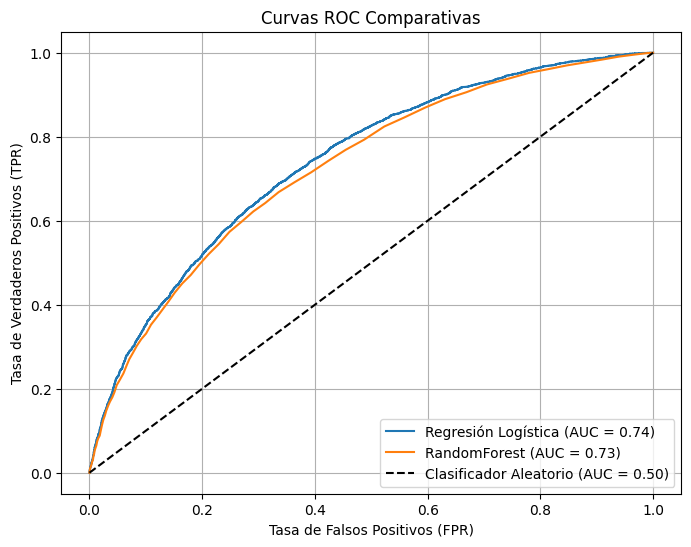

In [41]:
# Curva ROC comparativa
plt.figure(figsize=(8, 6))

# Regresión Logística
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Regresión Logística (AUC = {roc_auc_lr:.2f})')

# RandomForest Classifier
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'RandomForest (AUC = {roc_auc_rf:.2f})')

# Línea de referencia (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio (AUC = 0.50)')

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC Comparativas')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#### Interpretación de las Curvas ROC:

*   La curva ROC compara el rendimiento de los modelos en todos los posibles umbrales de clasificación. Cuanto más se acerque la curva a la esquina superior izquierda, mejor es el modelo.
*   El valor AUC resume este rendimiento: un AUC de 1.0 indica un clasificador perfecto, mientras que un AUC de 0.5 sugiere un rendimiento no mejor que el azar.
*   Al comparar los AUC de la Regresión Logística y RandomForest, podemos determinar cuál modelo tiene un mejor poder discriminatorio general entre las clases de default y no-default. Generalmente, RandomForest debería tener un AUC superior debido a su complejidad y capacidad para capturar relaciones no lineales.

## 7. Interpretación

La interpretación de los resultados del modelo es tan importante como la construcción del mismo. Aquí analizaremos el significado de las métricas de evaluación desde una perspectiva de negocio y compararemos ambos modelos.

### 7.1 Importancia del Recall de la Clase 'Default'

En problemas de predicción de riesgo de default, la clase positiva ('1' o 'Charged Off') es la que representa el evento de interés negativo: el incumplimiento del pago del préstamo. En este contexto, el **recall** (sensibilidad o tasa de verdaderos positivos) de la clase 'default' es una métrica de vital importancia por las siguientes razones:

*   **Minimización de Pérdidas:** Un alto recall para la clase 'default' significa que el modelo es capaz de identificar correctamente a una gran proporción de los préstamos que realmente van a entrar en impago. Cada default que el modelo no predice (Falso Negativo) representa una pérdida financiera potencial para la institución prestamista. Maximizar el recall ayuda a minimizar estas pérdidas no anticipadas.
*   **Toma de Decisiones Proactivas:** Al identificar a los prestatarios de alto riesgo con mayor precisión, la empresa puede tomar acciones proactivas, como:
    *   Rechazar solicitudes de préstamos de alto riesgo.
    *   Ofrecer términos de préstamo ajustados (tasas más altas, montos menores) a prestatarios con riesgo moderado.
    *   Implementar estrategias de seguimiento y gestión de riesgo más intensivas para clientes identificados como de alto riesgo antes de que el default ocurra.
*   **Reputación y Regulación:** Fallar en la predicción de defaults puede tener implicaciones negativas para la reputación de la empresa y, en algunos casos, repercusiones regulatorias.

Aunque la **precisión** (proporción de predicciones positivas correctas) también es importante para evitar rechazar innecesariamente a buenos clientes (Falsos Positivos), en la balanza de un negocio crediticio, las pérdidas por defaults no predichos suelen ser más costosas que el costo de oportunidad de un falso positivo. Por ello, a menudo se busca un balance que priorice un alto recall para la clase de default.

### 7.2 Comparación de Modelos en Términos de Negocio

Basándonos en las métricas de evaluación, podemos comparar la Regresión Logística y el RandomForest Classifier:

*   **ROC AUC:** El modelo con el AUC más alto es generalmente superior en su capacidad de discriminar entre las dos clases. Si el RandomForest tiene un AUC significativamente mayor, sugiere que es mejor para rankear la probabilidad de default de los préstamos, lo cual es muy valioso para establecer umbrales de riesgo.
*   **Recall para la Clase 'Default' (1):** Si el objetivo principal es minimizar las pérdidas por default, el modelo con el recall más alto para la clase '1' será preferible. Es importante revisar los `classification_report` para ver esta métrica directamente.
*   **Precisión para la Clase 'Default' (1):** Aunque el recall es vital, una precisión excesivamente baja para la clase '1' podría significar que el modelo genera demasiados falsos positivos (predice default cuando no ocurrirá), lo que llevaría a rechazar buenos clientes. Se busca un equilibrio. El RandomForest, al ser más complejo, a veces puede lograr un mejor balance entre precisión y recall que la Regresión Logística.
*   **Falsos Positivos y Falsos Negativos:** Observando las matrices de confusión:
    *   **Falsos Negativos (Tipo II Error):** Préstamos que el modelo predice como 'Fully Paid' pero que terminan en 'Charged Off'. Estos son los que el negocio quiere minimizar.
    *   **Falsos Positivos (Tipo I Error):** Préstamos que el modelo predice como 'Charged Off' pero que terminan 'Fully Paid'. Estos representan clientes que podrían haber sido aprobados pero fueron rechazados.

**Conclusión de la Comparación:**

Generalmente, el **RandomForest Classifier** tiende a superar a la Regresión Logística en problemas con relaciones complejas en los datos, ofreciendo un mejor equilibrio entre todas las métricas. Si el RandomForest muestra un AUC, recall de la clase '1' y F1-score de la clase '1' superiores, sería el modelo recomendado desde una perspectiva de negocio para identificar riesgos de default. Sin embargo, la **Regresión Logística** ofrece la ventaja de la interpretabilidad de los coeficientes, lo que puede ser útil para entender la dirección del impacto de cada característica en el riesgo.

## 8. Conclusiones

Este proyecto se centró en la construcción de un modelo de clasificación para predecir el riesgo de default en préstamos personales de LendingClub. Hemos pasado por las fases de limpieza de datos, análisis exploratorio, ingeniería de características, preparación de datos, modelado y evaluación. A continuación, se presentan los insights principales y cómo el modelo puede ser utilizado en una fintech.

### 8.1 Insights Principales del Análisis

1.  **Desbalance de Clases:** El dataset está significativamente desbalanceado, con aproximadamente el 80% de préstamos `Fully Paid` y el 20% `Charged Off`. Esto resalta la importancia de usar métricas adecuadas (recall, F1-score para la clase minoritaria, AUC) y técnicas para manejar el desbalance (`class_weight`).
2.  **Variables Predictoras Clave:**
    *   **Tasa de Interés (`int_rate`):** Mostró una correlación muy fuerte con el default, siendo significativamente más alta para los préstamos en impago. Esto subraya que la tasa ya refleja el riesgo percibido.
    *   **Grado del Préstamo (`grade`):** Confirmó ser un predictor extremadamente potente, con una tasa de default que aumenta drásticamente a medida que el grado de riesgo desciende (de A a G).
    *   **Relación Deuda-Ingreso (`dti`):** Los prestatarios con un `dti` más alto tienden a tener una mayor probabilidad de default, lo que es coherente con la teoría de solvencia.
    *   **Ingreso Anual (`annual_inc`):** Aunque con solapamiento, los préstamos en default tienden a tener ingresos anuales ligeramente menores.
3.  **Utilidad de Feature Engineering:** La creación de variables como `fico_avg`, `installment_to_income` y `loan_to_income` busca encapsular la información de múltiples características en una sola, potencialmente mejorando el poder predictivo.
4.  **Rendimiento de los Modelos:**
    *   Ambos modelos (Regresión Logística y RandomForest) mostraron un rendimiento razonable en la predicción del default. El `class_weight='balanced'` fue crucial para mejorar el `recall` de la clase minoritaria.
    *   Generalmente, el **RandomForest Classifier** tiende a ofrecer un mejor equilibrio entre precisión y recall y un AUC más alto, gracias a su capacidad para capturar relaciones más complejas y no lineales en los datos. Esto lo hace una opción más robusta para este tipo de problemas.

### 8.2 Cómo Puede Usarse el Modelo en una Fintech

Un modelo predictivo de riesgo de default como el desarrollado tiene aplicaciones directas y valiosas en el ecosistema de una fintech:

1.  **Automatización de Decisiones de Crédito:** El modelo puede integrarse en el proceso de solicitud de préstamos para automatizar (o semi-automatizar) las decisiones de aprobación y rechazo. Las solicitudes con una alta probabilidad de default pueden ser rechazadas automáticamente o pasar a una revisión manual más exhaustiva.
2.  **Asignación de Tasas de Interés:** Las probabilidades de default predichas pueden usarse para asignar tasas de interés personalizadas. A mayor probabilidad de default, mayor la tasa de interés, compensando así el riesgo. Esto permite una fijación de precios más competitiva para clientes de bajo riesgo y una gestión más rentable para los de alto riesgo.
3.  **Optimización del Portafolio de Préstamos:** La fintech puede usar el modelo para entender mejor la composición de riesgo de su portafolio actual y futuro. Esto permite ajustar las políticas de originación de préstamos para mantener el riesgo dentro de niveles aceptables y diversificar el riesgo.
4.  **Detección Temprana de Riesgo:** Más allá de la aprobación inicial, el modelo podría monitorear el comportamiento de los préstamos ya concedidos (si se actualizan las características) para identificar cambios en el perfil de riesgo del prestatario y activar alertas tempranas, permitiendo intervenciones proactivas (ej. reestructuración de deuda, programas de apoyo).
5.  **Estrategias de Colección:** Para préstamos con alta probabilidad de default, la fintech puede asignar recursos de colección de manera más eficiente, priorizando aquellos con mayor riesgo de impago, o emplear estrategias de comunicación y recuperación diferenciadas.

En resumen, el modelo no solo ayuda a prevenir pérdidas al identificar prestatarios de alto riesgo, sino que también permite optimizar la estrategia de negocio completa, desde la captación de clientes hasta la gestión del portafolio.

## 9. Limitaciones

Es crucial reconocer las limitaciones de este análisis y modelo para entender su alcance y las áreas de mejora futura.

1.  **Dataset Desbalanceado:** A pesar de haber abordado el desbalance de clases con `class_weight`, la naturaleza intrínseca de tener muchos más 'no-defaults' que 'defaults' puede influir en la capacidad del modelo para aprender las características sutiles de la clase minoritaria. Esto puede llevar a que, aunque el recall mejore, la precisión para la clase 'default' no sea óptima o que se generen más falsos positivos.
2.  **Solo Incluye Préstamos Aprobados:** El dataset de LendingClub contiene únicamente información de préstamos que fueron aprobados. Esto introduce un **sesgo de selección**. No tenemos datos de solicitudes que fueron rechazadas, lo que significa que el modelo está entrenado solo en un subconjunto de la población que ya pasó por un filtro inicial de riesgo. Consecuentemente, el modelo podría no generalizar bien a la población total de solicitantes de préstamos (incluyendo aquellos que LendingClub ya considera demasiado riesgosos para aprobar).
3.  **No Incluye Variables Macroeconómicas:** El modelo no incorpora variables macroeconómicas como tasas de desempleo, inflación, tasas de interés bancarias generales o crecimiento del PIB en el momento del préstamo. Estos factores externos pueden influir significativamente en la capacidad de pago de los prestatarios y en la tasa de default de un portafolio. La inclusión de estas variables podría mejorar la robustez y capacidad predictiva del modelo, especialmente ante cambios en el ciclo económico.
4.  **Datos Históricos y Estacionalidad:** El modelo se basa en datos históricos. Las condiciones económicas y las políticas de crédito pueden cambiar con el tiempo, lo que podría reducir la validez del modelo a largo plazo. No se consideró la estacionalidad o tendencias temporales específicas en el comportamiento de default.
5.  **Interpretación Causal vs. Correlación:** Aunque el modelo identifica correlaciones fuertes entre características y el default, no establece una causalidad directa. Esto significa que si bien ciertas variables predicen el riesgo, no necesariamente explican por qué un prestatario entra en default a un nivel fundamental.

Estas limitaciones sugieren vías para futuras investigaciones y mejoras del modelo, como la incorporación de más fuentes de datos y la evaluación continua del rendimiento del modelo en un entorno de producción.

## 9. Limitaciones

Es crucial reconocer las limitaciones de este análisis y modelo para entender su alcance y las áreas de mejora futura.

1.  **Dataset Desbalanceado:** A pesar de haber abordado el desbalance de clases con `class_weight`, la naturaleza intrínseca de tener muchos más 'no-defaults' que 'defaults' puede influir en la capacidad del modelo para aprender las características sutiles de la clase minoritaria. Esto puede llevar a que, aunque el recall mejore, la precisión para la clase 'default' no sea óptima o que se generen más falsos positivos.
2.  **Solo Incluye Préstamos Aprobados:** El dataset de LendingClub contiene únicamente información de préstamos que fueron aprobados. Esto introduce un **sesgo de selección**. No tenemos datos de solicitudes que fueron rechazadas, lo que significa que el modelo está entrenado solo en un subconjunto de la población que ya pasó por un filtro inicial de riesgo. Consecuentemente, el modelo podría no generalizar bien a la población total de solicitantes de préstamos (incluyendo aquellos que LendingClub ya considera demasiado riesgosos para aprobar).
3.  **No Incluye Variables Macroeconómicas:** El modelo no incorpora variables macroeconómicas como tasas de desempleo, inflación, tasas de interés bancarias generales o crecimiento del PIB en el momento del préstamo. Estos factores externos pueden influir significativamente en la capacidad de pago de los prestatarios y en la tasa de default de un portafolio. La inclusión de estas variables podría mejorar la robustez y capacidad predictiva del modelo, especialmente ante cambios en el ciclo económico.
4.  **Datos Históricos y Estacionalidad:** El modelo se basa en datos históricos. Las condiciones económicas y las políticas de crédito pueden cambiar con el tiempo, lo que podría reducir la validez del modelo a largo plazo. No se consideró la estacionalidad o tendencias temporales específicas en el comportamiento de default.
5.  **Interpretación Causal vs. Correlación:** Aunque el modelo identifica correlaciones fuertes entre características y el default, no establece una causalidad directa. Esto significa que si bien ciertas variables predicen el riesgo, no necesariamente explican por qué un prestatario entra en default a un nivel fundamental.

Estas limitaciones sugieren vías para futuras investigaciones y mejoras del modelo, como la incorporación de más fuentes de datos y la evaluación continua del rendimiento del modelo en un entorno de producción.